In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mis_dro.likelihood import cholesky_param_to_covariance
from mis_dro.bayes_conjugates import *
from mis_dro.dataset import portfolio_dataset

/tmp/dcs-tmp.u1604520/ipykernel_41071/3891927575.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
dgp = "DowJones"
replication = 0

mmc2_dir = Path("/dcs/pg23/u1604520/misdro/datasets/mmc2")
assert mmc2_dir.exists()
# returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Assets_Returns", header=None)
data, data_eval = portfolio_dataset(dgp, replication, mmc2_dir)

portfolio_npl_samples_csv = Path(f"/dcs/pg23/u1604520/misdro/results/npl_samples/mmd_portfolio_crash_diag/4f4995f7-c6ba-48b9-b91d-b43580288b92/npl_sample_{replication}.csv")
npl_df = pd.read_csv(portfolio_npl_samples_csv, index_col=False, header=None)
npl_samples = npl_df.values

num_posterior_samples = npl_samples.shape[0]
dim = data.shape[1]

In [10]:
# Bayes posterior
posterior = "multivariate_normal_diag"
theta_prior = default_prior_params(posterior, dim=dim)
theta_posterior = get_posterior_params(posterior, data, theta_prior)
mu_post, _, alpha_post, beta_post = theta_posterior

In [11]:
beta_post/alpha_post

array([0.04057533, 0.04100913, 0.03770421, 0.03823524, 0.03825088,
       0.03859809, 0.04258008, 0.0387068 , 0.03983371, 0.03842409,
       0.0388272 , 0.03789782, 0.04092908, 0.03908122, 0.04066143,
       0.03821686, 0.03831963, 0.04402028, 0.04295745, 0.03881216,
       0.03786503, 0.04141063, 0.03938676, 0.03832867, 0.04025129,
       0.038403  , 0.03881895, 0.03826569])

In [6]:
bayes_cov = (1.0 / float(iota_post)) * Psi_post
empirical_cov = np.cov(data,  rowvar=False)

In [8]:
print(np.diag(bayes_cov))# - np.diag(empirical_cov))

[0.01475305 0.01508331 0.01279234 0.01316511 0.01315761 0.01339612
 0.01605115 0.01346184 0.01425793 0.01329681 0.01357059 0.01291997
 0.01502056 0.01371041 0.01477263 0.01314433 0.01321936 0.01716092
 0.01651038 0.01352915 0.01290052 0.01530853 0.01391809 0.01320686
 0.01448853 0.01325658 0.01353389 0.01316887]


In [9]:
print(np.diag(empirical_cov))

[0.00374354 0.00420041 0.00070631 0.00126745 0.00128509 0.0016523
 0.0058685  0.00176781 0.00295833 0.00146707 0.00189359 0.00091139
 0.00411621 0.00216431 0.00383696 0.0012485  0.00135693 0.0073845
 0.00625569 0.00187954 0.00087653 0.00462805 0.00248758 0.0013676
 0.00340333 0.0014463  0.00188671 0.00130069]


In [5]:
# NPL posterior with full covariance
npl_means = np.zeros((num_posterior_samples, dim))
npl_covs = np.zeros((num_posterior_samples, dim, dim))
for i in range(num_posterior_samples):
    npl_means[i] = npl_samples[i,:dim]
    npl_covs[i] = cholesky_param_to_covariance(dim, npl_samples[i,dim:])

In [6]:
mean_npl_mean = npl_means.mean(axis=0)
mean_npl_cov = npl_covs.mean(axis=0)

In [7]:
mean_npl_mean - mu_post

array([ 0.00731006, -0.00782063,  0.00226203, -0.00254679, -0.003639  ,
       -0.00126059, -0.00020014, -0.00165192, -0.00213487, -0.0020128 ,
       -0.00893714,  0.00524983, -0.01322652, -0.00085273,  0.00078928,
        0.00132851, -0.00763944, -0.00970568, -0.01867318,  0.00331055,
       -0.00246168, -0.00106996, -0.00276803,  0.00197907, -0.00499266,
       -0.0002288 ,  0.00320261, -0.00256201])

In [8]:
np.diag(bayes_cov)

NameError: name 'bayes_cov' is not defined

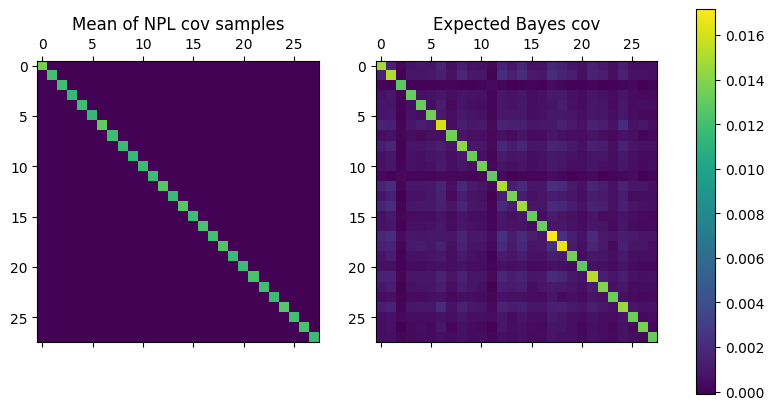

In [9]:
# Create a figure and axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

bayes_cov = (1.0 / float(iota_post)) * Psi_post
vmin = np.min([bayes_cov, mean_npl_cov])
vmax = np.max([bayes_cov, mean_npl_cov])

# Plot the first matrix
c1 = ax1.matshow(mean_npl_cov, cmap='viridis', vmin=vmin, vmax=vmax)
ax1.set_title('Mean of NPL cov samples')

# Plot the second matrix
c2 = ax2.matshow(bayes_cov, cmap='viridis', vmin=vmin, vmax=vmax)
ax2.set_title('Expected Bayes cov')

# Create a shared colorbar
cbar = fig.colorbar(c1, ax=[ax1, ax2], orientation='vertical')

fig.show()


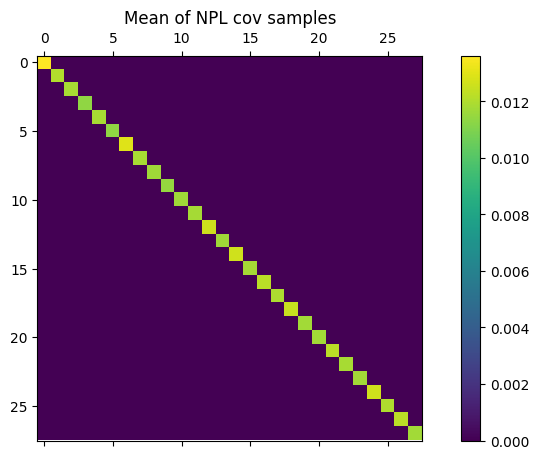

In [10]:
# Create a figure and axes
fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))

bayes_cov = (1.0 / float(iota_post)) * Psi_post
vmin = np.min([mean_npl_cov])
vmax = np.max([mean_npl_cov])

# Plot the first matrix
c1 = ax1.matshow(mean_npl_cov, cmap='viridis', vmin=vmin, vmax=vmax)
ax1.set_title('Mean of NPL cov samples')

# # Plot the second matrix
# c2 = ax2.matshow(bayes_cov, cmap='viridis', vmin=vmin, vmax=vmax)
# ax2.set_title('Expected Bayes cov')

# Create a shared colorbar
cbar = fig.colorbar(c1, ax=ax1, orientation='vertical')

fig.show()


In [9]:
data.shape

(52, 28)

In [4]:
import jax.numpy as jnp
from mis_dro.npl import *
from mis_dro.models import *

In [4]:
d = data.shape[1]
mu_init = jnp.mean(data, axis=0).reshape((d,))
cov_matrix = jnp.eye(d)#jnp.cov(data, rowvar=False)
L = jnp.linalg.cholesky(cov_matrix)
diag_idx = jnp.diag_indices(L.shape[0])
diag_entries = L[diag_idx]
L = L.at[diag_idx].set(jnp.log(diag_entries))
vec_triu_init = L[jnp.tril_indices(L.shape[0])]
triu_size = upper_triangular_size(d)
theta_init = jnp.zeros(d + triu_size)
theta_init = theta_init.at[:d].set(mu_init)
theta_init = theta_init.at[d:].set(vec_triu_init)
npl_cov = cholesky_param_to_covariance(dim, theta_init[dim:])
np.allclose(npl_cov, cov_matrix)


ValueError: operands could not be broadcast together with shapes (406,406) (28,28) 

In [12]:
triu_size

406

In [7]:
# # Define mean vector (1D array)
# mean = [0, 0]  # For a 2-dimensional distribution

# # Define covariance matrix (2D array)
# covariance = [[1, 0.5],   # Variance and covariances
#               [0.5, 1]]

# # Number of samples to generate
# num_samples = 20

# # Generate samples
# data = np.random.multivariate_normal(mean, covariance, num_samples)
# num_posterior = 50

In [8]:
jnp.cov(data, rowvar=False)

Array([[0.92933315, 0.27371612],
       [0.27371612, 0.604235  ]], dtype=float32)

In [5]:
theta_sample = sample_npl(
    data,
    "npl_mmd",
    "multivariate_normal",
    num_posterior_samples=2,
    seed=0,
    lengthscale=-1,
    generator=np.random.default_rng(seed=0),
    dim=dim
)

In [6]:
model = multivariate_GaussianModel(data.shape[0], dim, known_cov=False)
m = data.shape[0]
n = data.shape[0]

In [7]:
def obj_fun(theta, x, n, l, key):
    y = model.sample(
        theta, key
    )  # Returnes self.m random samples from the model with parameter theta
    # # # FIXME handle dimensions
    if dim > 1:
            # Compute kernel Gram matrices
        kyy = k_comp(y, y) #, self.l
        kxy = k_comp(y, x) #, self.l
    else:
        kyy = k_jax(y, y, l)
        kxy = k_jax(y, x, l)
    # print(kyy)
    # print(kxy)
    # first sum
    diag_elements = jnp.diag_indices_from(kyy)
    kyy = kyy.at[diag_elements].set(jnp.repeat(0, m))
    sum1 = jnp.sum(kyy)
    

    # second sum
    sum2 = jnp.sum(kxy)
    mmd = (1 / (m * (m - 1))) * sum1 - (2 / (n * m)) * sum2

    # Return first two terms of squared MMD; note that the third term does not depend on theta!
    return mmd


In [6]:
key = jax.random.PRNGKey(0)
ls = np.linspace(0.000001, 100, num=10)
theta = model.init_params(data, key=key)
for l in ls:
    mmd = obj_fun(theta, data, n, l, key)
    print(mmd, l)

NameError: name 'model' is not defined

In [6]:
num_posterior_samples = 2
npl_means = np.zeros((num_posterior_samples, dim))
npl_covs = np.zeros((num_posterior_samples, dim, dim))
for i in range(num_posterior_samples):
    npl_means[i] = theta_sample[i,:dim]
    npl_covs[i] = cholesky_param_to_covariance(dim, theta_sample[i,dim:])

In [7]:
mean_npl_mean = npl_means.mean(axis=0)
mean_npl_cov = npl_covs.mean(axis=0)

In [8]:
mean_npl_mean

array([ 1.81993931e-02,  1.46989641e-02,  3.99840600e-03,  9.58195259e-03,
        4.26860352e-03,  1.20085771e-02,  1.59139978e-03,  2.54885823e-03,
        1.53733669e-02,  9.02610132e-03,  1.27500868e-02,  5.60736889e-03,
        2.25161933e-02,  6.59636105e-03,  2.48454860e-03,  4.68733406e-03,
        1.09427241e-02,  2.53705941e-02,  3.86984274e-02,  2.12465064e-04,
        5.41626103e-03,  2.15956364e-02,  4.16125730e-03, -1.97123853e-04,
        4.12300302e-03,  2.23404309e-03,  4.24669124e-05,  4.71440796e-03])

In [9]:
mean_npl_cov

array([[0.01330406, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.01359988, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.01153634, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

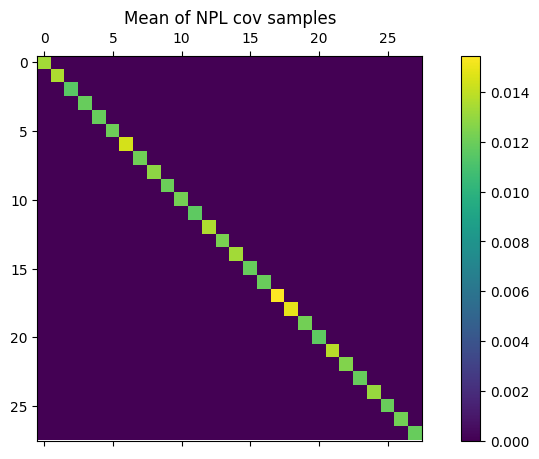

In [10]:
# Create a figure and axes
fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))

# bayes_cov = (1.0 / float(iota_post)) * Psi_post
vmin = np.min([mean_npl_cov])
vmax = np.max([mean_npl_cov])

# Plot the first matrix
c1 = ax1.matshow(mean_npl_cov, cmap='viridis', vmin=vmin, vmax=vmax)
ax1.set_title('Mean of NPL cov samples')

# # Plot the second matrix
# c2 = ax2.matshow(bayes_cov, cmap='viridis', vmin=vmin, vmax=vmax)
# ax2.set_title('Expected Bayes cov')

# Create a shared colorbar
cbar = fig.colorbar(c1, ax=ax1, orientation='vertical')

fig.show()

In [106]:
def cholesky_param_to_covariance_(dim, L_flat):
    # Reshape the flat array into a lower triangular matrix
    L = np.zeros((dim, dim))
    tril_indices = np.tril_indices(dim)
    L[tril_indices] = L_flat
    # Diagonal elements of L should be strictly positive to ensure positive definiteness
    L[np.diag_indices(dim)] = np.exp(np.diag(L))

    # Return the covariance matrix
    return L @ L.T

In [125]:
cov_matrix = jnp.eye(dim)#jnp.cov(data, rowvar=False)
L = jnp.linalg.cholesky(cov_matrix)
diag_idx = jnp.diag_indices(L.shape[0])
diag_entries = L[diag_idx]
L = L.at[diag_idx].set(jnp.log(diag_entries))
vec_triu_init = L[jnp.tril_indices(L.shape[0])]
triu_size = upper_triangular_size(dim)
theta_init = jnp.zeros(dim + triu_size)
theta_init = theta_init.at[dim:].set(vec_triu_init)
npl_cov = cholesky_param_to_covariance_jax(dim, theta_init[dim:])


In [126]:
np.array_equal(npl_cov, cov_matrix)

True

In [127]:
np.allclose(npl_cov, cov_matrix)

True

In [8]:
def cholesky_param_to_covariance_jax(L_flat):
    """
    Converts a flattened lower triangular matrix to a covariance matrix.

    L_flat: The flattened lower triangular part of the matrix.
    dim: The dimensionality of the covariance matrix.
    """
    # Reshape the flat array into a lower triangular matrix
    L = jnp.zeros((dim, dim))
    tril_indices = jnp.tril_indices(dim)
    L = L.at[tril_indices].set(L_flat)

    # Diagonal elements of L should be strictly positive to ensure positive definiteness
    L = L.at[jnp.diag_indices(dim)].set(jnp.exp(jnp.diag(L)))

    # Return the covariance matrix
    return L @ L.T